# Test Transforms

Showcase of **every** image transformation available in `utils/transforms.py`:

- `eval_transform` — baseline (resize → ToTensor → ImageNet normalize)
- `train_transform_default` — resize → Ben Graham preprocessing → normalize
- `preprocess_image` — Ben Graham preprocessing (luminance normalization + CLAHE + circular mask)
- `train_transform_retina_all` — RandAugment + ElasticTransform + random erasing
- `train_transform_retina_strong` — crop / rotate / color-jitter / blur / erasing
- `mixup_data`, `mosaic_data`, `copy_paste_data` — label-preserving sample mixing
- `build_train_transform` — the registry used by `main.py --augmentation`

Run the cells in order. A synthetic retina-like image is used when no dataset image is reachable.

In [4]:
import sys
import os
from pathlib import Path

# The notebook lives in notebooks/; the project root is one level up.
notebook_dir = Path.cwd()
project_root = str(notebook_dir.parent if (notebook_dir / "notebooks").exists() or (notebook_dir.parent / "utils").exists() else notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("project_root =", project_root)

project_root = /home/andremitri/code/LEMUR


[i] Using real image: /exp/andremitri/mamba/aaryapatel98/indian-diabetic-retinopathy-image-dataset/versions/1/B.%20Disease%20Grading/B. Disease Grading/1. Original Images/b. Testing Set/IDRiD_087.jpg


# 1. eval_transform

Baseline: resize → ToTensor → ImageNet normalization. No augmentation.

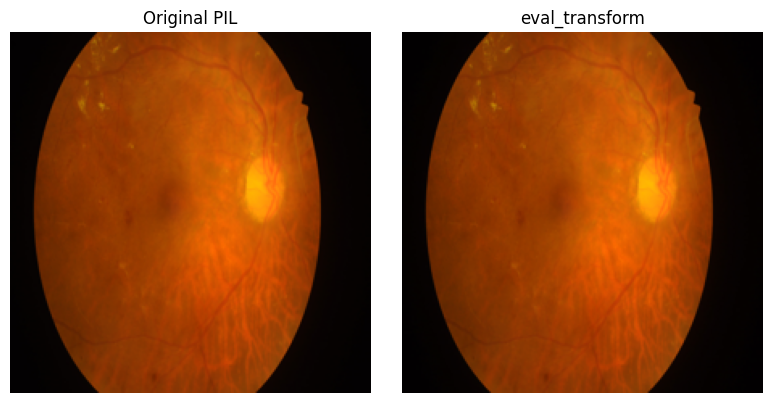

Output tensor shape: (3, 224, 224) | dtype: torch.float32
Value range (normalized): min=-2.08 max=2.25


In [6]:
out = eval_transform(IMG_SIZE)(img)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original PIL"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(to_img(out)); plt.title("eval_transform"); plt.axis("off")
plt.tight_layout(); plt.show()

print("Output tensor shape:", tuple(out.shape), "| dtype:", out.dtype)
print("Value range (normalized): min=%.2f max=%.2f" % (out.min().item(), out.max().item()))

# 2. train_transform_default

Resize → Ben Graham preprocessing → normalize. The `default` augmentation mode in `main.py`.

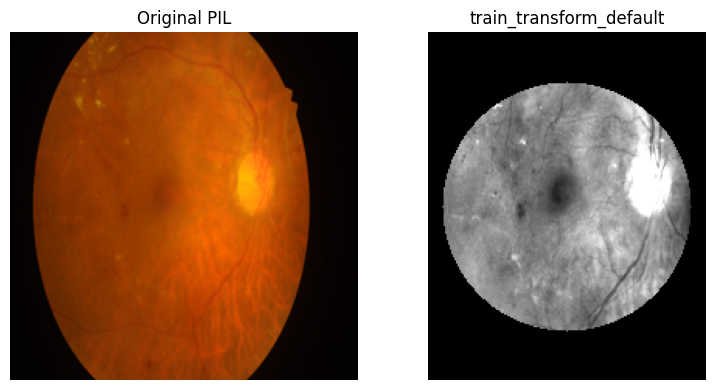

In [7]:
tfm = train_transform_default(IMG_SIZE)
out = tfm(img)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(img); plt.title("Original PIL"); plt.axis("off")
plt.subplot(1, 2, 2); plt.imshow(to_img(out)); plt.title("train_transform_default"); plt.axis("off")
plt.tight_layout(); plt.show()

# 3. preprocess_image (Ben Graham)

Background crop → green-channel luminance normalization → CLAHE → circular mask.

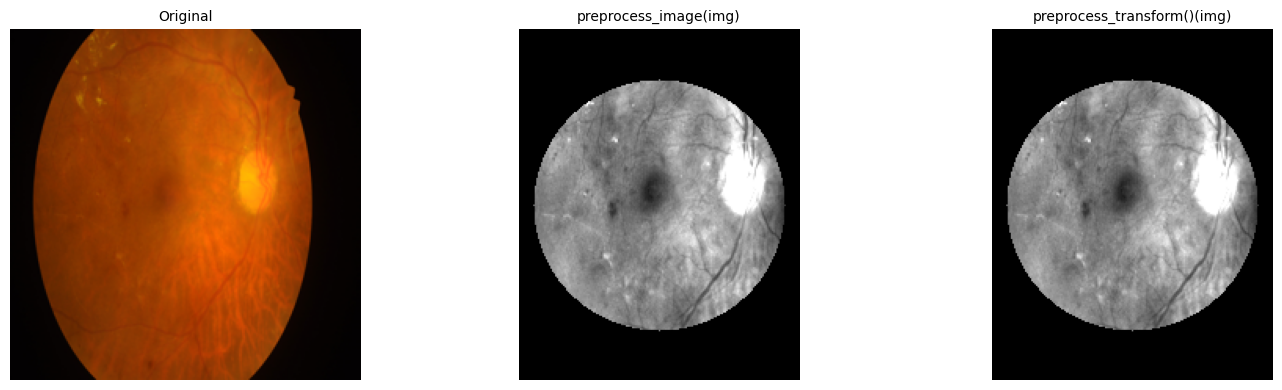

In [8]:
preprocessed = preprocess_image(img, sigmaX=30)
via_lambda = preprocess_transform()(img)

show([img, preprocessed, via_lambda],
     ["Original", "preprocess_image(img)", "preprocess_transform()(img)"],
     ncols=3, figsize=(15, 4))

# 4. train_transform_retina_all

RandAugment + ElasticTransform + random erasing. The `retina_all` mode.

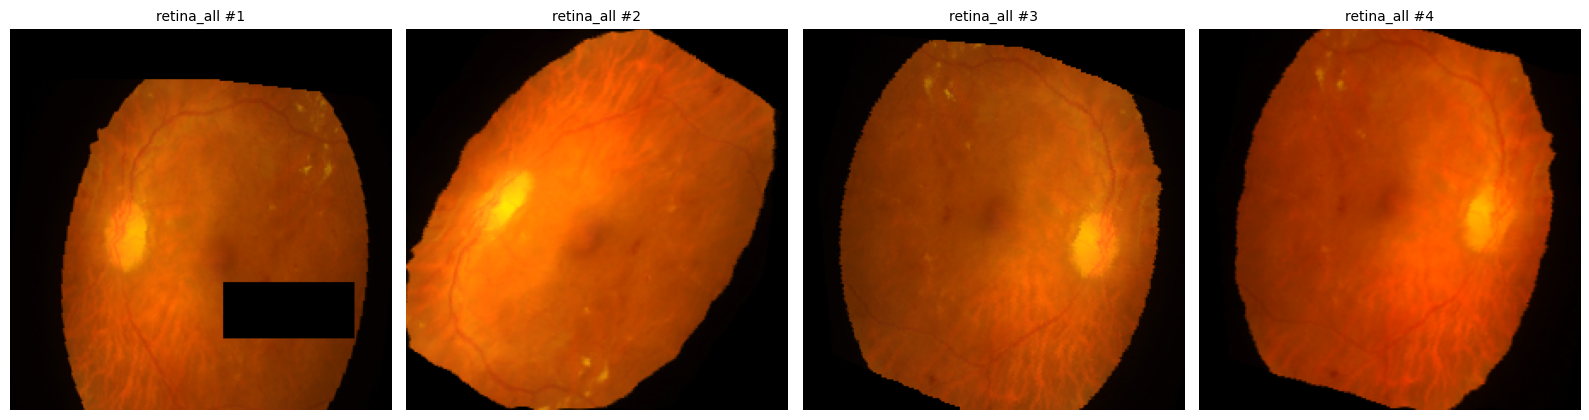

In [9]:
tfm = train_transform_retina_all(IMG_SIZE)
outs = [tfm(img) for _ in range(4)]
show([to_img(o) for o in outs], [f"retina_all #{i+1}" for i in range(4)])

# 5. train_transform_retina_strong

Resized-crop + rotate + flips + color jitter + Gaussian blur + erasing. The `retina_strong` mode.

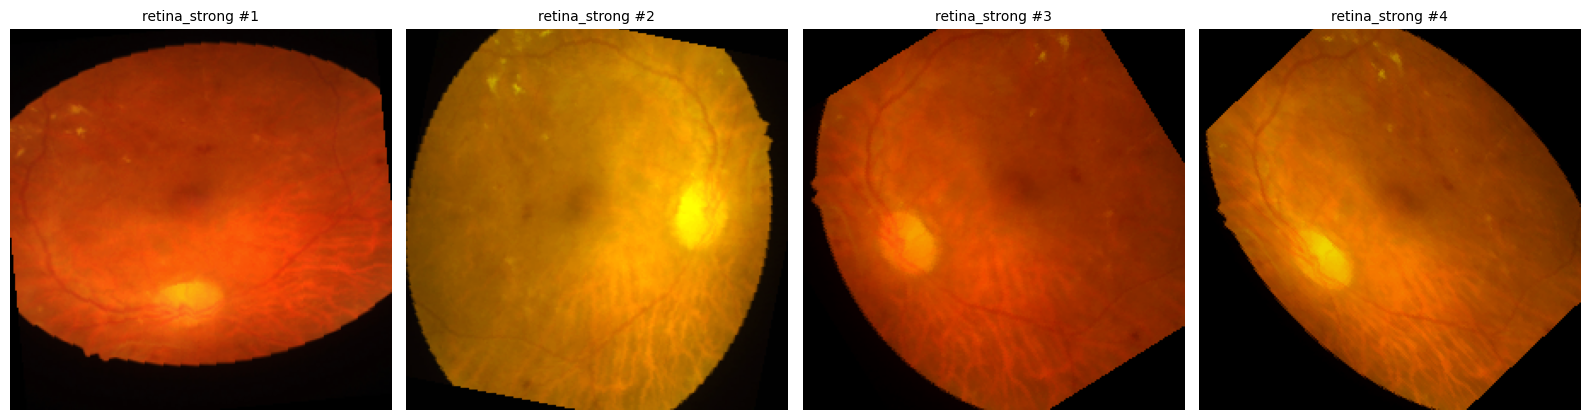

In [10]:
tfm = train_transform_retina_strong(IMG_SIZE)
outs = [tfm(img) for _ in range(4)]
show([to_img(o) for o in outs], [f"retina_strong #{i+1}" for i in range(4)])

# 6. mixup_data

Blends two images (and one-hot labels) with a Beta-sampled lambda.

lambda = 0.017
mixed label (one-hot): [0.017 0.983 0.    0.    0.   ]


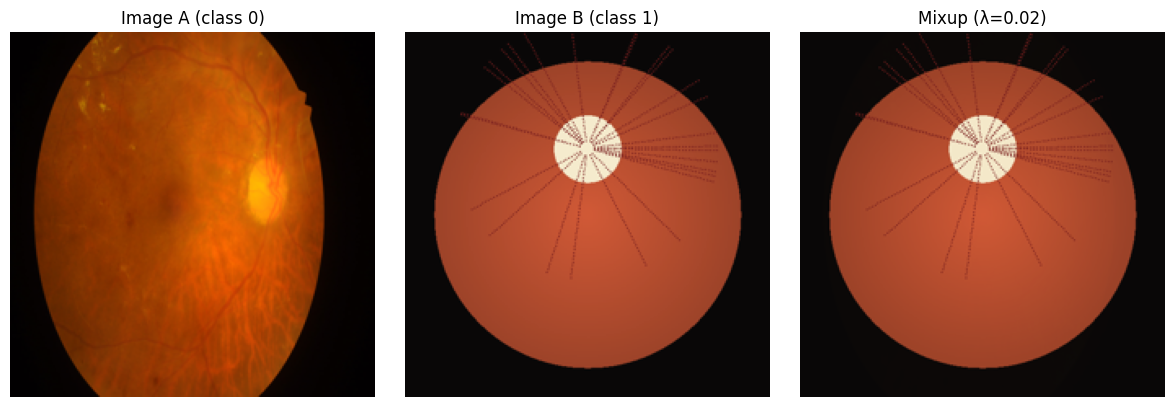

In [11]:
x1 = base_tfm(img)
x2 = base_tfm(img2)
y1, y2 = 0, 1

x_mix, y_mix, lam = mixup_data(x1, x2, y1, y2, alpha=0.4)
print(f"lambda = {lam:.3f}")
print("mixed label (one-hot):", y_mix.numpy().round(3))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(to_img(x1)); plt.title(f"Image A (class {y1})"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(to_img(x2)); plt.title(f"Image B (class {y2})"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(to_img(x_mix)); plt.title(f"Mixup (λ={lam:.2f})"); plt.axis("off")
plt.tight_layout(); plt.show()

# 7. mosaic_data

Stitches 4 images into a 2×2 grid, averaging their labels.

Mosaic label (one-hot, averaged): [0.25 0.25 0.25 0.25 0.  ]


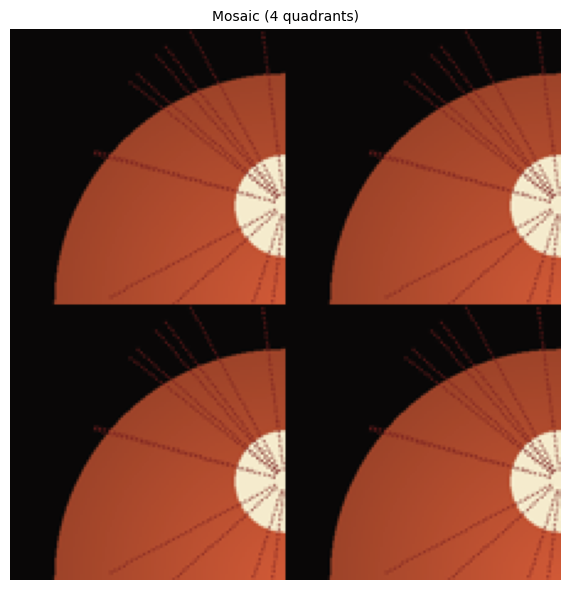

In [12]:
tensors = [base_tfm(synthetic_fundus((512, 512)).resize((IMG_SIZE, IMG_SIZE))) for _ in range(4)]
labels = [0, 1, 2, 3]

out, y = mosaic_data(tensors, labels)
print("Mosaic label (one-hot, averaged):", y.numpy().round(3))
show([to_img(out)], ["Mosaic (4 quadrants)"], ncols=1, figsize=(6, 6))

# 8. copy_paste_data

Pastes a random patch from image B onto image A, mixing labels by patch area.

Copy-paste label (one-hot): [0.891 0.109 0.    0.    0.   ]


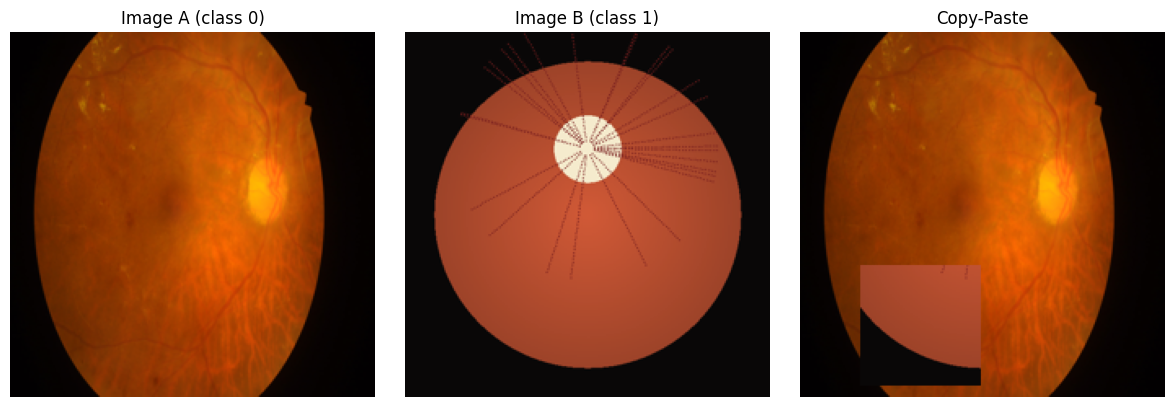

In [13]:
x1 = base_tfm(img)
x2 = base_tfm(img2)
y1, y2 = 0, 1
x_cp, y_cp = copy_paste_data(x1, x2, y1, y2)
print("Copy-paste label (one-hot):", y_cp.numpy().round(3))

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(to_img(x1)); plt.title(f"Image A (class {y1})"); plt.axis("off")
plt.subplot(1, 3, 2); plt.imshow(to_img(x2)); plt.title(f"Image B (class {y2})"); plt.axis("off")
plt.subplot(1, 3, 3); plt.imshow(to_img(x_cp)); plt.title("Copy-Paste"); plt.axis("off")
plt.tight_layout(); plt.show()

# 9. build_train_transform (registry)

Central dispatcher used during training (see `--augmentation` in `main.py`).

In [14]:
for mode in ["default", "none", "retina_all", "retina_strong"]:
    t = build_train_transform(mode, IMG_SIZE)
    print(f"build_train_transform('{mode}', {IMG_SIZE}):")
    print("  ", t)
    print()

build_train_transform('default', 224):
   Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    Lambda()
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

build_train_transform('none', 224):
   Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    Lambda()
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

build_train_transform('retina_all', 224):
   Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-45.0, 45.0], interpolation=nearest, expand=False, fill=0)
    RandAugment(num_ops=2, magnitude=9, num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
    RandomApply(
    p=0.3
    ElasticTransform(alpha=[50.0, 50.0], sigma=[5.0, 5.0], interpolation=InterpolationMode.BILINEAR, fill=[